# 2606-Data Ecosystems and Governance in Organizations

# 1. Setup

## 1.1. Import Libraries

In [11]:
### Data manipulation
import pandas as pd
import numpy as np

### Visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Statistical testing
import scipy.stats as stats

### Fairness metrics
from fairlearn.metrics import demographic_parity_difference

### Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 1.2. Load Clean Datasets
- We will use Jan 1, 2024 as our baseline date based on our data's processing timestamps

In [12]:
app_df = pd.read_csv('data/processed/applications_clean.csv')
spend_df = pd.read_csv('data/processed/spending_behavior.csv')

## 1.3. Feature Engineering

### 1.3.1. Calculate Age

In [13]:
app_df['applicant_info_date_of_birth'] = pd.to_datetime(app_df['applicant_info_date_of_birth'])
baseline_date = pd.to_datetime('2024-01-01')
app_df['age'] = (baseline_date - app_df['applicant_info_date_of_birth']).dt.days // 365

### 1.3.2. Aggregate Spending
- We need to pivot the spending data so each category becomes its own column

In [14]:
spend_pivot = spend_df.pivot_table(
    index='app_id', 
    columns='category', 
    values='amount', 
    fill_value=0
).reset_index()

## 1.4. Dataframe Adjustments

### 1.4.1. Create master DF
- Merge everything into one master analytical dataframe

In [15]:
merged_df = pd.merge(app_df, spend_pivot, on='app_id', how='left')

### 1.4.2. Handlibng missing values
- Fill NaNs with 0 for any applicants who didn't have specific spending records

In [16]:
spending_categories = spend_pivot.columns.drop('app_id')
merged_df[spending_categories] = merged_df[spending_categories].fillna(0)

In [17]:
merged_df.head()

,app_id,processing_timestamp,applicant_info_full_name,applicant_info_email,applicant_info_ssn,applicant_info_ip_address,applicant_info_gender,applicant_info_date_of_birth,applicant_info_zip_code,financials_annual_income,...,Fitness,Gambling,Groceries,Healthcare,Insurance,Rent,Shopping,Transportation,Travel,Utilities
0,app_200,2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,...,0.0,0.0,0.0,0.0,0.0,790.0,480.0,0.0,0.0,0.0
1,app_037,NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,...,0.0,0.0,0.0,243.0,0.0,608.0,0.0,0.0,0.0,0.0
2,app_215,NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,...,0.0,0.0,0.0,0.0,0.0,109.0,0.0,0.0,0.0,0.0
3,app_024,NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077.0,103000.0,...,575.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,app_184,2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,1999-05-21,10080.0,57000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 2. Bias Analysis

In this section, the gender bias in the dataset will be thoroughly examined, using the Disparate Impact (DI) Ratio and Approval Rate per age group as follows:
$$DI_{\text{Gender}} = \frac{P(\text{Approved} \mid \text{Gender} = \text{Female})}{P(\text{Approved} \mid \text{Gender} = \text{Male})}$$
$$P(\text{Approved} \mid \text{Age} \in g) = \frac{\sum I(\text{Approved} \cap \text{Age} \in g)}{\sum I(\text{Age} \in g)}$$

## 2.1. Approval Rates by Gender
- 'decision_loan_approved' is a boolean (True/False).
- Taking the mean() of a boolean column gives us the exact percentage of True values (the approval rate).

In [18]:
gender_approval = merged_df.groupby('applicant_info_gender')['decision_loan_approved'].mean().reset_index()
gender_approval.rename(columns={'decision_loan_approved': 'approval_rate'}, inplace=True)

print("Approval Rates by Gender:")
print(gender_approval.to_string(index=False))
print("\n")

Approval Rates by Gender:
applicant_info_gender  approval_rate
               Female       0.508000
                 Male       0.659919
              Unknown       0.666667




## 2.2. Calculate Disparate Impact (DI) Ratio
- We will test Female as the potentially unprivileged group against Male as the privileged group
- The four-fifths rule states a DI < 0.8 indicates potential disparate impact

In [19]:
rate_male = gender_approval[gender_approval['applicant_info_gender'] == 'Male']['approval_rate'].values[0]
rate_female = gender_approval[gender_approval['applicant_info_gender'] == 'Female']['approval_rate'].values[0]

di_ratio_gender = rate_female / rate_male

print(f"Disparate Impact Analysis:")
print(f"Disparate Impact (DI) Ratio (Female/Male): {di_ratio_gender:.4f}")

if di_ratio_gender < 0.8:
    print("DI Ratio is below 0.8. This violates the four-fifths rule and indicates potential gender bias!")
else:
    print("DI Ratio is 0.8 or above. No strict disparate impact flagged by the four-fifths rule.")

Disparate Impact Analysis:
Disparate Impact (DI) Ratio (Female/Male): 0.7698
DI Ratio is below 0.8. This violates the four-fifths rule and indicates potential gender bias!


## 2.3. Visualizing the Results

### 2.3.1. Loan Approval Rates by Gender
- Horizontal dashed line for the 80% threshold

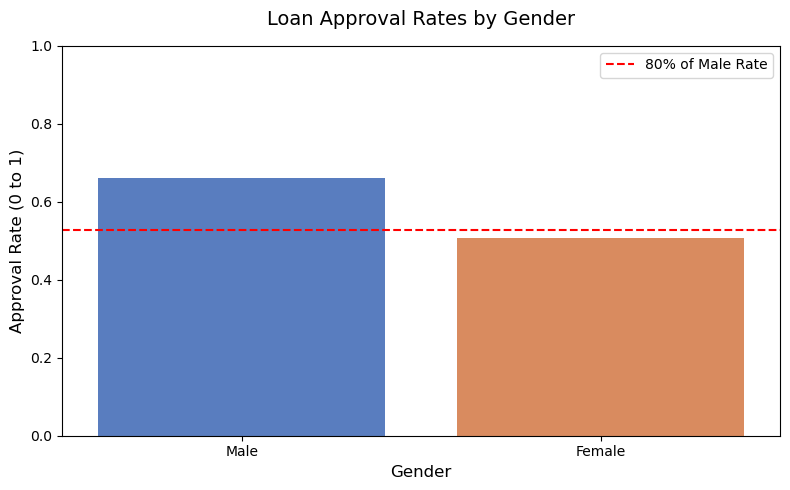

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x='applicant_info_gender', 
    y='approval_rate', 
    data=gender_approval, 
    palette='muted',
    order=['Male', 'Female'],
    ax=ax
)

ax.set_title('Loan Approval Rates by Gender', fontsize=14, pad=15)
ax.set_ylabel('Approval Rate (0 to 1)', fontsize=12)
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylim(0, 1) 

### Add horizontal threshold line 
ax.axhline(y=rate_male * 0.8, color='red', linestyle='--', label='80% of Male Rate')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 2.3.2. Disparate Impact (DI) Ratio
- Red bar if DI fails the four-fifths rule, green if it passes
- Horizontal dashed line for the 80% threshold

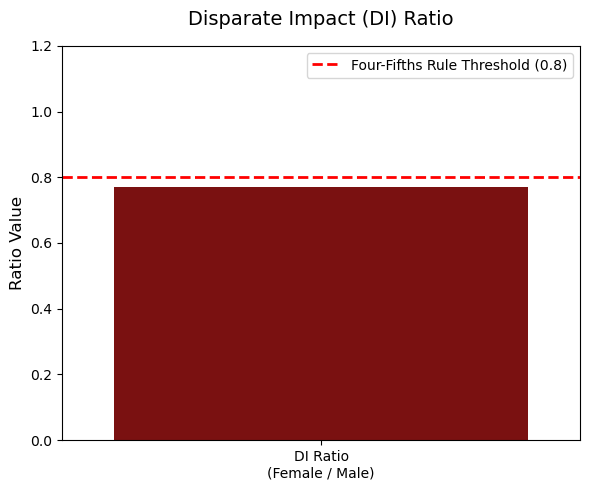

In [35]:
### Create a small temporary dataframe just for this plot
di_df = pd.DataFrame({'Metric': ['DI Ratio\n(Female / Male)'], 'Value': [di_ratio_gender]})

bar_color = 'darkred' if di_ratio_gender < 0.8 else 'darkgreen'

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    x='Metric', 
    y='Value', 
    data=di_df, 
    color=bar_color,
    ax=ax
)

ax.set_title('Disparate Impact (DI) Ratio', fontsize=14, pad=15)
ax.set_ylabel('Ratio Value', fontsize=12)
ax.set_xlabel('')
ax.set_ylim(0, max(1.2, di_ratio_gender + 0.2)) 

### Add horizontal threshold line
ax.axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='Four-Fifths Rule Threshold (0.8)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# 3. Exploratory Data Analysis

## 3.1 Univariate Analysis

(Target Variable Check, Numerical values and distribution, Categorial values)

## 3.2 Correlation Analysis

## 3.3 Bivariate Analysis

(Correlation between two Variables)


## 3.4 Multivariate Analysis 